<a href="https://colab.research.google.com/github/sanjhna7/CODING-SAMURAI-INTERNSHIP-TASK/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
#Description: This program uses artificial recurrent neural network called Long Short Term Memory(LSTM)
#             to predict the closing stock price of a corperation (Apple Inc.) using the past 60 day stock Price

In [179]:
#import libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [180]:
!pip install yfinance --quiet
import yfinance as yf

# get the stock quote
df = yf.download('AAPL', start='2019-01-01', end='2026-5-15')

# show the data
df

/tmp/ipykernel_16368/688181855.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2019-01-01', end='2026-5-15')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.469196,37.689856,36.593681,36.750278,148158800
2019-01-03,33.736988,34.574540,33.691907,34.161694,365248800
2019-01-04,35.177212,35.246021,34.119003,34.292207,234428400
2019-01-07,35.098904,35.312446,34.617252,35.281600,219111200
2019-01-08,35.767986,36.021864,35.238882,35.485638,164101200
...,...,...,...,...,...
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800
2026-05-11,292.679993,293.880005,290.230011,291.980011,42247300


In [181]:
#Get the no of coloumns and rows in the data set
df.shape

(1852, 5)

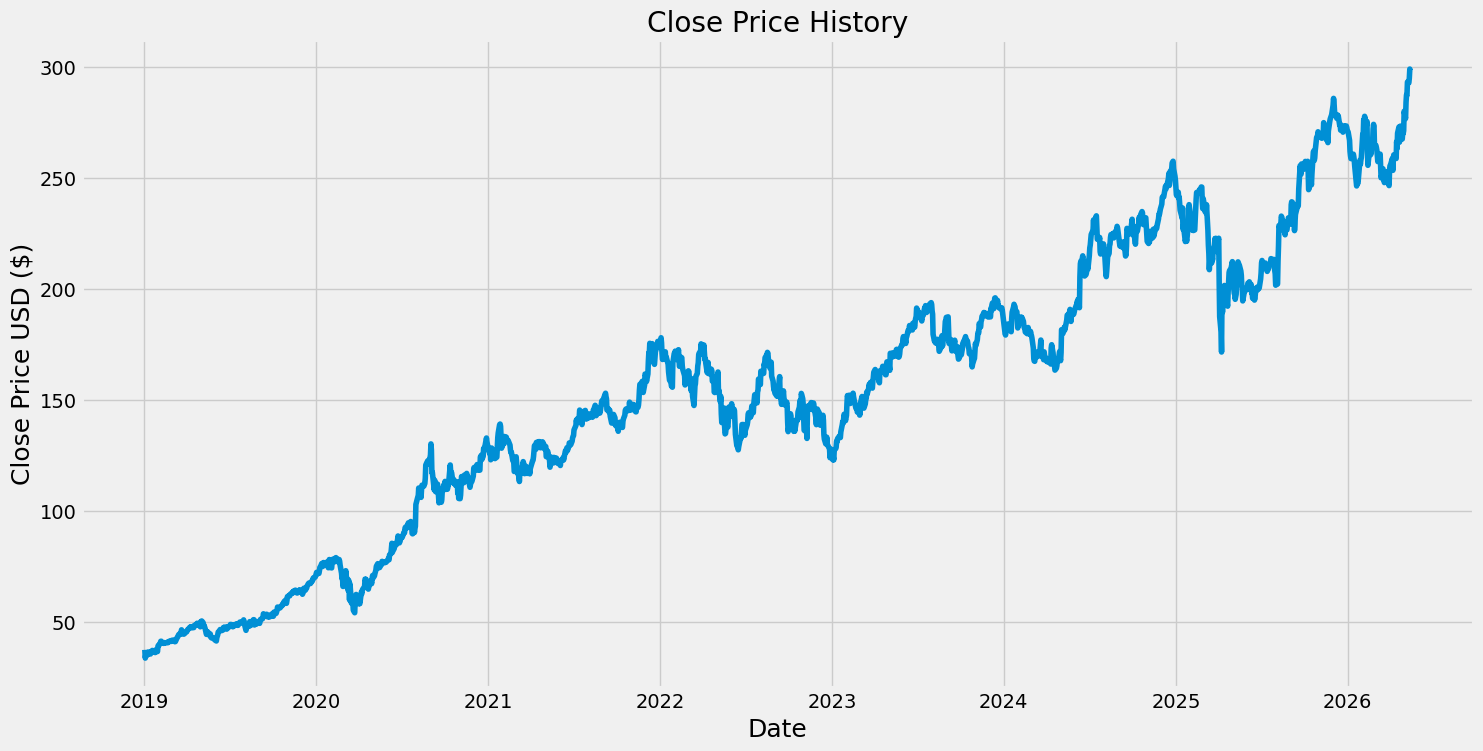

In [182]:
#Visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [183]:
#Create a new dataframe with close coloumn
data = df.filter(['Close'])
#Convert the dataframe to a numpy array
dataset = data.values
#Get the number of rows to train the model on
training_data_len = math.ceil( len(dataset) * .8 )

training_data_len
#

1482

In [184]:
# Fix: Extract Close column from MultiIndex and Scale the Data
dataset = df['Close'].values

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01407674],
       [0.        ],
       [0.00543208],
       ...,
       [0.98464919],
       [1.        ],
       [0.99751067]])

In [185]:
#Create the training Data set
#create the trained Scaled Training Data Set
train_data = scaled_data[0:training_data_len, :]

#Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i <= 60:
        print(x_train)
        print(y_train)
        print()

[array([0.01407674, 0.        , 0.00543208, 0.00513673, 0.0076603 ,
       0.00995124, 0.01038979, 0.00903846, 0.00698918, 0.00973653,
       0.01140999, 0.01223328, 0.01309239, 0.00994236, 0.01049717,
       0.00940539, 0.01393358, 0.01262702, 0.01117731, 0.02063642,
       0.02170131, 0.02177289, 0.02600576, 0.02862783, 0.02868148,
       0.02572833, 0.02590811, 0.02502733, 0.02633949, 0.02570138,
       0.02625863, 0.0259171 , 0.02637541, 0.02736403, 0.02649227,
       0.02820884, 0.02934128, 0.02943119, 0.02991647, 0.02837063,
       0.03000632, 0.03079722, 0.03050959, 0.0296019 , 0.0277865 ,
       0.0281549 , 0.03353835, 0.03534483, 0.03606381, 0.03787926,
       0.04002725, 0.04173482, 0.04039574, 0.04186064, 0.0480889 ,
       0.04445801, 0.04238192, 0.04062937, 0.04213924, 0.04236395])]
[np.float64(0.04346938731172095)]



In [186]:
#Convert the x_train and y_train into numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

#Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

(1422, 60, 1)

In [187]:
#Build LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [188]:
#Compile the Model
model.compile(optimizer='adam', loss='mean_squared_error')

In [189]:
#train
model.fit(x_train,y_train,batch_size=1, epochs=16)

Epoch 1/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - loss: 0.0015
Epoch 2/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 5.3845e-04
Epoch 3/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 3.8436e-04
Epoch 4/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 3.3653e-04
Epoch 5/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 2.6272e-04
Epoch 6/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 2.3649e-04
Epoch 7/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 2.5086e-04
Epoch 8/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 2.0146e-04
Epoch 9/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 2.0822e-04
Epoch 10/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 1.8964e-04
Epoch 11/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 1.6959e-04
Epoch 12/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 1.7655e-04
Epoch 13/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 1.6741e-04
Epoch 14/20
1422/1422 ━━━

In [190]:
#Create the testing Data set
#create new array containing Scaled Values from index 1423 to 1853
test_data = scaled_data[training_data_len - 60: , :]
#create data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:,:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])


In [191]:
#Convert the data to numpy array
x_test = np.array(x_test)

In [192]:
#Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


In [193]:
#Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [194]:
#Get the root mean square error (RMSE)
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse

np.float64(9.13927340399138)

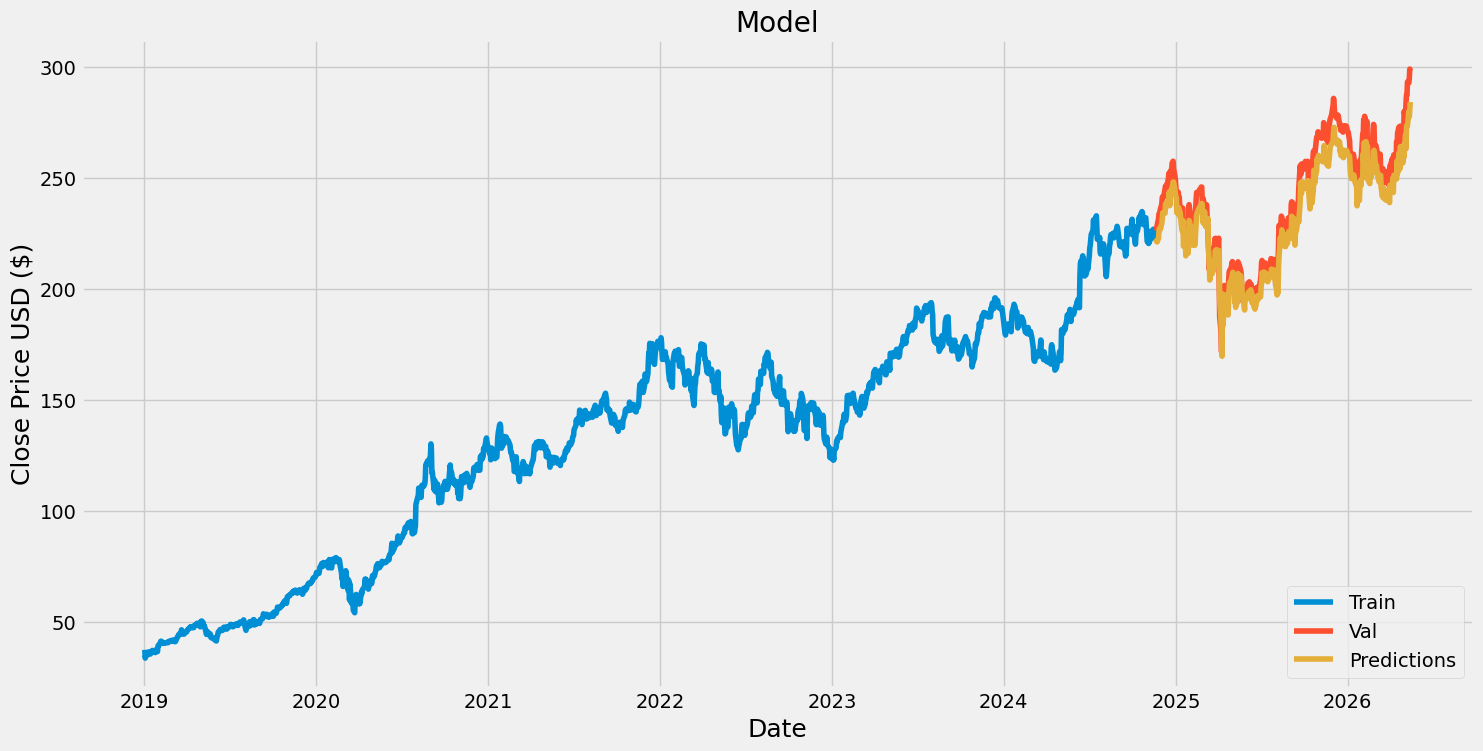

In [195]:
# Fix: Correctly extract the data for plotting
data = df[['Close']]
train = data[:training_data_len]
valid = data[training_data_len:].copy()
valid['Predictions'] = predictions

# Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [196]:
#show the valid and predicted prices
valid


Price,Close,Predictions
Ticker,AAPL,
Date,,
2024-11-20,227.546204,220.750290
2024-11-21,227.069244,221.686508
2024-11-22,228.410645,221.025116
2024-11-25,231.391632,222.659485
2024-11-26,233.567719,225.473480
...,...,...
2026-05-08,293.050018,273.289490
2026-05-11,292.679993,279.890411


In [197]:
#Get the Quote
apple_quote = yf.download('AAPL', start='2019-01-01', end='2026-5-15')
#Create a new data frame - Fix: use direct indexing for MultiIndex columns
new_df = apple_quote['Close']
#Get the last 60 day closing price values and convert the dataframe to an array
last_60_days = new_df[-60:].values
#Scale the data between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days)
#Create an empty list
X_test = []
#Append the past 60 days
X_test.append(last_60_days_scaled)
#Convert the X_test data set to a numpy array
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#get the predicted scale price
pred_price = model.predict(X_test)
#undo the scaling
pred_price = scaler.inverse_transform(pred_price)
print(pred_price)

/tmp/ipykernel_16368/1553552366.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_quote = yf.download('AAPL', start='2019-01-01', end='2026-5-15')
[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[282.1546]]


In [198]:
#Get the Quote
apple_quote2 = yf.download('AAPL', start='2026-5-14', end='2026-5-15')
print(apple_quote2['Close'])

/tmp/ipykernel_16368/2001694764.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_quote2 = yf.download('AAPL', start='2026-5-14', end='2026-5-15')
[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2026-05-14  298.209991
